### The University of Melbourne, School of Computing and Information Systems
# COMP90086 Computer Vision, 2025 Semester 2

## Assignment 2

**Student Name:**    `YU LUO`

**Student ID:**     `1528667`

This iPython notebook is a template which you should use for your Assignment 1 submission. This file should be submitted at the **Assignment 2: Code** link on the LMS.

In addition to this file, you should submit a written report explaining your results at the **Assignment 2: Report** link on the LMS. Please see the assignment specification for details on what must be included in the report for each question.

*Adding proper comments to your code is MANDATORY.*

## 1. The image recognition task

In [1]:
# Global reproducibility
import os, random, numpy as np, tensorflow as tf

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"  # deterministic TF ops

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Optional (TensorFlow ≥2.9): enforce determinism
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

print(f"Seeds set to {SEED}")

/Users/yuluo/Desktop/UNIMELB/COMP90086/a2/comp90086_env/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Seeds set to 42


## 2. CNN architecture

### 2.0 Setup

#### 2.0.1 Loading Dataset

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# Path to the image folders
train_dir = "A2/train"
val_dir = "A2/val"

# Load training dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="binary",
    color_mode="grayscale",
    image_size=(28, 28),
    batch_size=64, # mini-batch size
    shuffle=True
)

# Load validation dataset
val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    labels="inferred",
    label_mode="binary",
    color_mode="grayscale",
    image_size=(28, 28),
    batch_size=64, # mini-batch size
    shuffle=False
)

# Scale pixel values from 0-255 to 0-1
normalization_layer = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

# Optional: cache + prefetch for performance
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

# Data augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomFlip("vertical"),
])

Found 12000 files belonging to 2 classes.
Found 12000 files belonging to 2 classes.


#### 2.0.2 Helper Functions

Plotting the Training/Validation Accuracy and Loss

In [3]:
# Function to plot training history
def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs = range(1, len(acc) + 1)

    # Accuracy plot
    plt.figure(figsize=(6,4))
    plt.plot(epochs, acc, 'b-', label='Training accuracy')
    plt.plot(epochs, val_acc, 'r-', label='Validation accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

    # Loss plot
    plt.figure(figsize=(6,4))
    plt.plot(epochs, loss, 'b-', label='Training loss')
    plt.plot(epochs, val_loss, 'r-', label='Validation loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

Build a specific cnn model from a given config

In [4]:
# Function to build a model from a given architecture config
def build_model_from_config(config, input_shape=(28, 28, 1)):
    # Build the model as a sequential model
    model = models.Sequential()

    model.add(layers.InputLayer(input_shape=input_shape))
    # Add data augmentation to the input data for better generalisation
    model.add(data_augmentation) 
    # Add convolutional layers as specified in config
    for conv in config['conv_layers']:
        model.add(layers.Conv2D(
            filters=conv['filters'],
            kernel_size=conv['kernel_size'],
            activation='relu', # use relu as the activation function
            padding='same' # same padding means the output size is the same as the input size
        ))
        # Add a consistent (2x2) max pooling layer to reduce the spatial dimensions of the output
        model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Flatten())
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dense(1, activation='sigmoid'))
    return model


### 2.1 CNN Experiements

#### 2.1.1 Basic Experiements (Kernel Size, Network Depth, Network Width)

##### 2.1.1.1 Model Configurations

In [5]:
cnn_model_configs = [
    # Group 1: Varying Kernel Size in a Single Convolutional Layer
    # Purpose: To investigate how the receptive field size of a single 
    # convolutional layer affects model performance.
    # Rationale: The letter patches in the dataset are typically 5, 7, or 9 pixels square, 
    # so kernel size may influence the model's ability to capture entire letter shapes 
    # versus finer details.
    {
        "name": "1conv_16f_7x7",
        "conv_layers": [
            {"filters": 16, "kernel_size": (7, 7)}
        ],
        # Intuition: A large 7x7 kernel may capture the whole letter shape in one operation,
        # testing whether a single, broad filter is sufficient for the classification task.
    },
    {
        "name": "1conv_16f_5x5",
        "conv_layers": [
            {"filters": 16, "kernel_size": (5, 5)}
        ],
        # Intuition: A 5x5 kernel offers a middle ground, capturing larger features than 3x3
        # but with more focus than 7x7. It may be well-suited for picking up the distinct
        # horizontal and vertical lines that define the letters with moderate receptive field.
    },
    {
        "name": "1conv_16f_3x3",
        "conv_layers": [
            {"filters": 16, "kernel_size": (3, 3)}
        ],
        # Intuition: A small 3x3 kernel is ideal for detecting local features such as
        # edges and corners, which are fundamental components of letter shapes. This model
        # tests whether learning from small, local regions is effective for this task.
    },

    # Group 2: Exploring Network Depth and Filter Progression
    # Purpose: To examine how increasing the number of convolutional layers and 
    # varying the number of filters per layer affects the model's ability to 
    # learn more complex and abstract features.
    {
        "name": "2conv_16f_3x3_16f_3x3",
        "conv_layers": [
            {"filters": 16, "kernel_size": (3, 3)},
            {"filters": 16, "kernel_size": (3, 3)}
        ],
        # Intuition: This model adds a second convolutional layer without increasing the number of filters,
        # isolating the effect of increased depth on feature learning.
        # Tests the benefit of a deeper architecture for capturing complex patterns.
    },
    {
        "name": "2conv_16f_3x3_32f_3x3",
        "conv_layers": [
            {"filters": 16, "kernel_size": (3, 3)},
            {"filters": 32, "kernel_size": (3, 3)}
        ],
        # Intuition: Increasing the filter count in the second layer allows the model to
        # learn more abstract features from the first layer's output. 
    },
    {
        "name": "2conv_32f_3x3_32f_3x3",
        "conv_layers": [
            {"filters": 32, "kernel_size": (3, 3)},
            {"filters": 32, "kernel_size": (3, 3)}
        ],
        # Intuition: This model uses same small kernel size in both layers but 
        # different filter count, aiming for a balance between model complexity and performance.
        
    },
    {
        "name": "2conv_32f_3x3_64f_3x3",
        "conv_layers": [
            {"filters": 32, "kernel_size": (3, 3)},
            {"filters": 64, "kernel_size": (3, 3)}
        ],
        # Intuition: This model uses a slightly more aggressive increase in network width,
        # and seeks to see if there are more benefits of introducing more filters.
    },
    {
        "name": "2conv_64f_3x3_64f_3x3",
        "conv_layers": [
            {"filters": 64, "kernel_size": (3, 3)},
            {"filters": 64, "kernel_size": (3, 3)}
        ],
        # Intuition: A very aggressive"wide and deep" model that tests whether a larger number of filters
        # in both layers leads to improved accuracy. This high-capacity model may be
        # particularly effective at handling challenging noisy backgrounds, such as random rectangles.
    },
]

##### 2.1.1.2 Model Trainning for Experiements

Training model: 1conv_16f_7x7
Epoch 1/20


/Users/yuluo/Desktop/UNIMELB/COMP90086/a2/comp90086_env/lib/python3.9/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5085 - loss: 0.6961 - val_accuracy: 0.5001 - val_loss: 0.6933
Epoch 2/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5106 - loss: 0.6931 - val_accuracy: 0.5013 - val_loss: 0.6931
Epoch 3/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5097 - loss: 0.6928 - val_accuracy: 0.5091 - val_loss: 0.6929
Epoch 4/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5127 - loss: 0.6925 - val_accuracy: 0.4989 - val_loss: 0.6971
Epoch 5/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5159 - loss: 0.6923 - val_accuracy: 0.5143 - val_loss: 0.6920
Epoch 6/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5339 - loss: 0.6893 - val_accuracy: 0.5277 - val_loss: 0.6915
Epoch 7/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5465 - loss: 0.6861 - val_accuracy: 0.5312 - val_loss: 0.6900
Epoch 8/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5663 - loss: 0.6784 - val_accuracy: 0.5458 - val_

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 16)     │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       200,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 604,901 (2.31 MB)

 Trainable params: 201,633 (787.63 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 403,268 (1.54 MB)

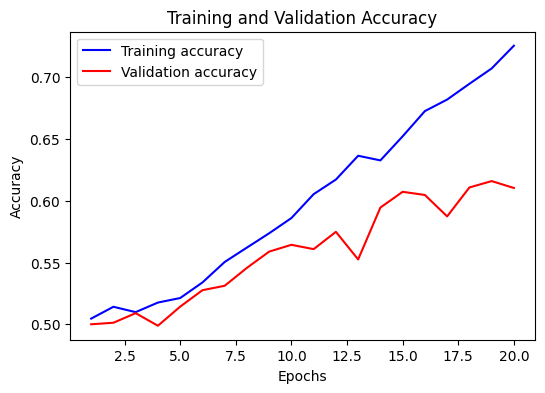

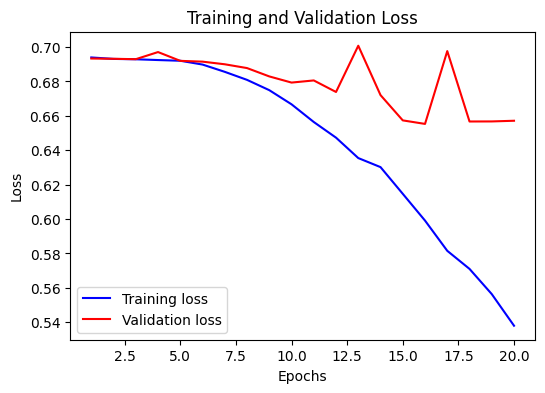

Training model: 1conv_16f_5x5
Epoch 1/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5122 - loss: 0.7104 - val_accuracy: 0.5008 - val_loss: 0.6932
Epoch 2/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5015 - loss: 0.6932 - val_accuracy: 0.5002 - val_loss: 0.6931
Epoch 3/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5084 - loss: 0.6931 - val_accuracy: 0.4997 - val_loss: 0.6931
Epoch 4/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5032 - loss: 0.6932 - val_accuracy: 0.4989 - val_loss: 0.6931
Epoch 5/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4985 - loss: 0.6933 - val_accuracy: 0.5002 - val_loss: 0.6931
Epoch 6/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4996 - loss: 0.6931 - val_accuracy: 0.4996 - val_loss: 0.6931
Epoch 7/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4940 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 8/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4977 - l

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 16)     │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       200,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 603,749 (2.30 MB)

 Trainable params: 201,249 (786.13 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 402,500 (1.54 MB)

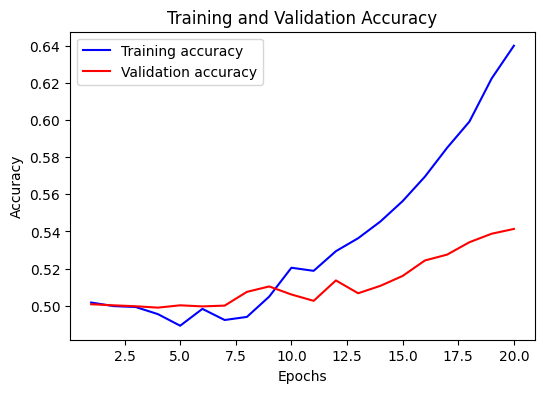

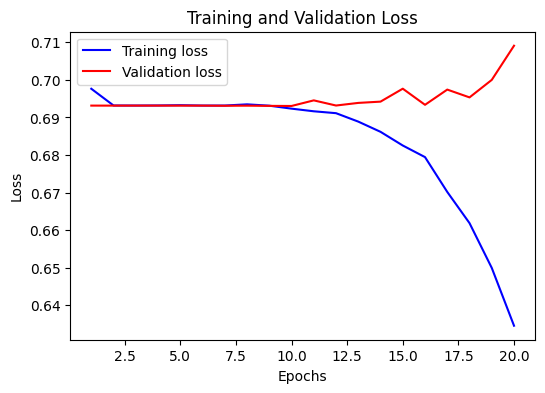

Training model: 1conv_16f_3x3
Epoch 1/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4952 - loss: 0.7042 - val_accuracy: 0.5097 - val_loss: 0.6929
Epoch 2/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5019 - loss: 0.6927 - val_accuracy: 0.5054 - val_loss: 0.6934
Epoch 3/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5199 - loss: 0.6912 - val_accuracy: 0.5088 - val_loss: 0.6934
Epoch 4/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5228 - loss: 0.6911 - val_accuracy: 0.5107 - val_loss: 0.6930
Epoch 5/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5317 - loss: 0.6896 - val_accuracy: 0.5125 - val_loss: 0.6932
Epoch 6/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5415 - loss: 0.6883 - val_accuracy: 0.5100 - val_loss: 0.6953
Epoch 7/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5510 - loss: 0.6850 - val_accuracy: 0.5107 - val_loss: 0.6945
Epoch 8/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5532 - l

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │       200,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 602,981 (2.30 MB)

 Trainable params: 200,993 (785.13 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 401,988 (1.53 MB)

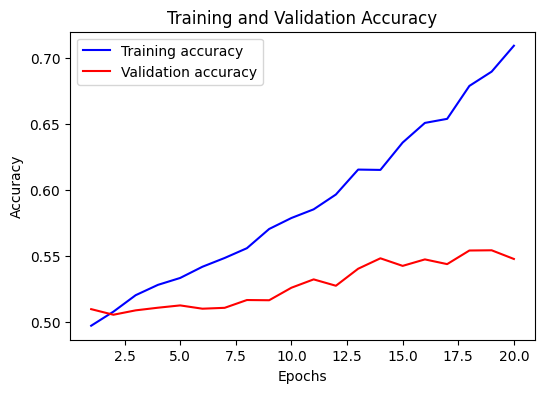

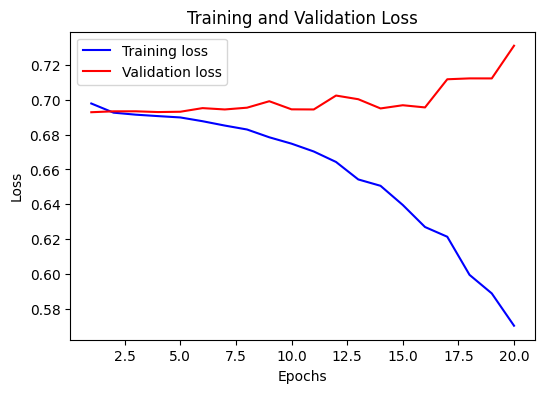

Training model: 2conv_16f_3x3_16f_3x3
Epoch 1/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5013 - loss: 0.6965 - val_accuracy: 0.4998 - val_loss: 0.6932
Epoch 2/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4953 - loss: 0.6934 - val_accuracy: 0.5002 - val_loss: 0.6930
Epoch 3/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5112 - loss: 0.6928 - val_accuracy: 0.5306 - val_loss: 0.6907
Epoch 4/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5467 - loss: 0.6883 - val_accuracy: 0.5834 - val_loss: 0.6772
Epoch 5/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5869 - loss: 0.6735 - val_accuracy: 0.6048 - val_loss: 0.6621
Epoch 6/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6184 - loss: 0.6507 - val_accuracy: 0.6142 - val_loss: 0.6543
Epoch 7/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6492 - loss: 0.6267 - val_accuracy: 0.6777 - val_loss: 0.5978
Epoch 8/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 158,357 (618.59 KB)

 Trainable params: 52,785 (206.19 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 105,572 (412.39 KB)

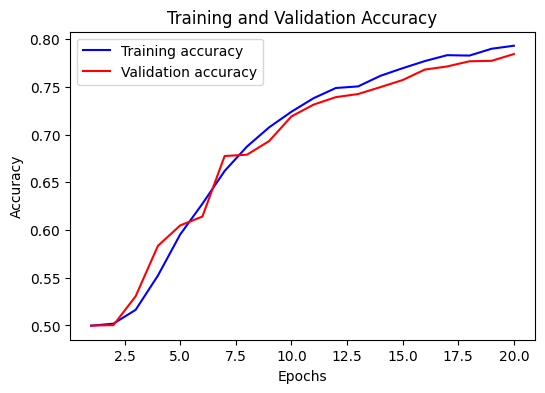

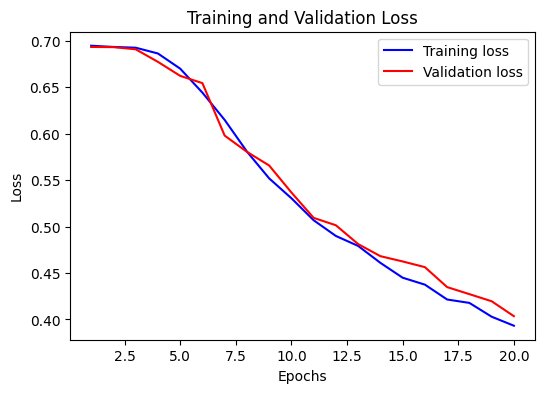

Training model: 2conv_16f_3x3_32f_3x3
Epoch 1/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.4965 - loss: 0.6946 - val_accuracy: 0.5001 - val_loss: 0.6932
Epoch 2/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5034 - loss: 0.6932 - val_accuracy: 0.5051 - val_loss: 0.6931
Epoch 3/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5100 - loss: 0.6932 - val_accuracy: 0.5027 - val_loss: 0.6928
Epoch 4/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5298 - loss: 0.6912 - val_accuracy: 0.5117 - val_loss: 0.6929
Epoch 5/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5554 - loss: 0.6836 - val_accuracy: 0.5867 - val_loss: 0.6733
Epoch 6/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6001 - loss: 0.6637 - val_accuracy: 0.6227 - val_loss: 0.6472
Epoch 7/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6292 - loss: 0.6412 - val_accuracy: 0.6651 - val_loss: 0.6162
Epoch 8/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 1568)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │       100,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 315,845 (1.20 MB)

 Trainable params: 105,281 (411.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 210,564 (822.52 KB)

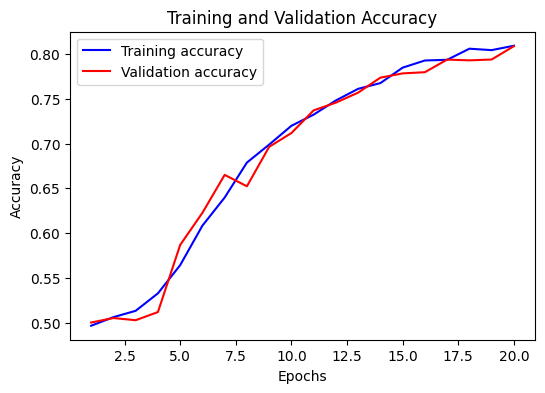

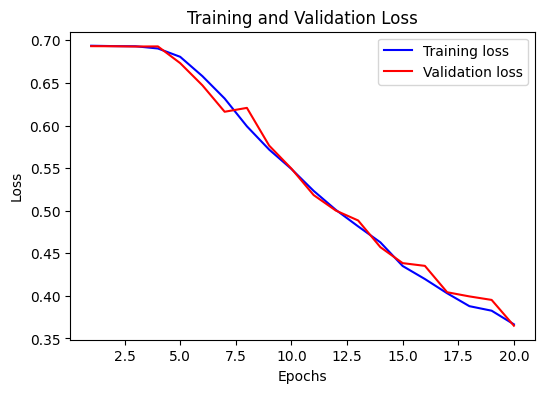

Training model: 2conv_32f_3x3_32f_3x3
Epoch 1/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.5006 - loss: 0.6954 - val_accuracy: 0.5036 - val_loss: 0.6931
Epoch 2/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.4990 - loss: 0.6931 - val_accuracy: 0.5179 - val_loss: 0.6923
Epoch 3/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.5288 - loss: 0.6915 - val_accuracy: 0.5590 - val_loss: 0.6879
Epoch 4/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.5511 - loss: 0.6852 - val_accuracy: 0.5197 - val_loss: 0.6853
Epoch 5/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.5840 - loss: 0.6739 - val_accuracy: 0.5993 - val_loss: 0.6636
Epoch 6/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.5997 - loss: 0.6588 - val_accuracy: 0.6178 - val_loss: 0.6534
Epoch 7/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.6362 - loss: 0.6362 - val_accuracy: 0.6470 - val_loss: 0.6315
Epoch 8/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accur

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 1568)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │       100,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 330,149 (1.26 MB)

 Trainable params: 110,049 (429.88 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 220,100 (859.77 KB)

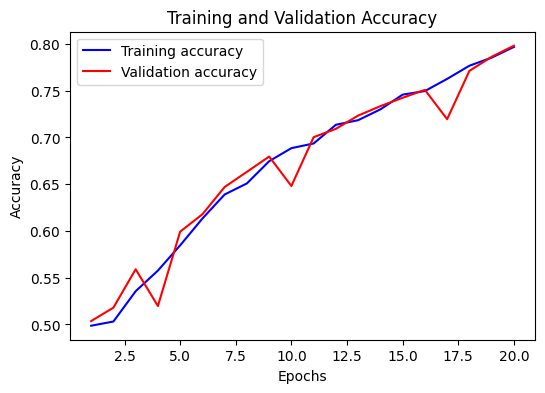

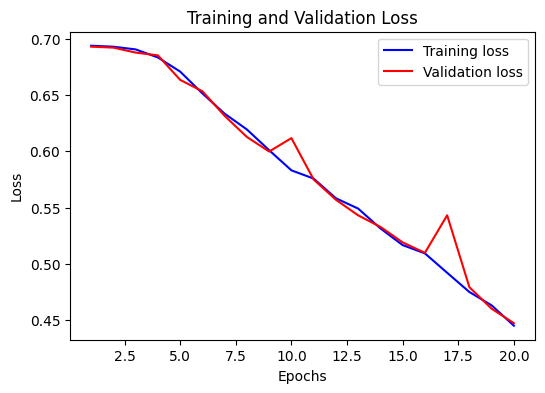

Training model: 2conv_32f_3x3_64f_3x3
Epoch 1/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.5093 - loss: 0.6946 - val_accuracy: 0.5003 - val_loss: 0.6931
Epoch 2/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.5100 - loss: 0.6931 - val_accuracy: 0.5002 - val_loss: 0.6930
Epoch 3/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.5136 - loss: 0.6930 - val_accuracy: 0.5248 - val_loss: 0.6925
Epoch 4/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.5364 - loss: 0.6908 - val_accuracy: 0.5554 - val_loss: 0.6866
Epoch 5/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.5713 - loss: 0.6782 - val_accuracy: 0.6060 - val_loss: 0.6527
Epoch 6/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.6397 - loss: 0.6344 - val_accuracy: 0.6784 - val_loss: 0.6058
Epoch 7/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.6910 - loss: 0.5848 - val_accuracy: 0.7120 - val_loss: 0.5531
Epoch 8/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accu

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │       200,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 658,949 (2.51 MB)

 Trainable params: 219,649 (858.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 439,300 (1.68 MB)

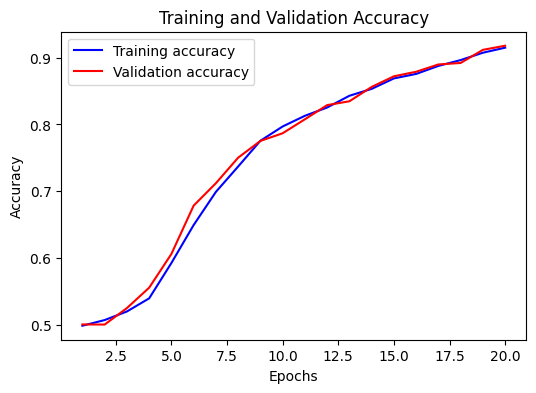

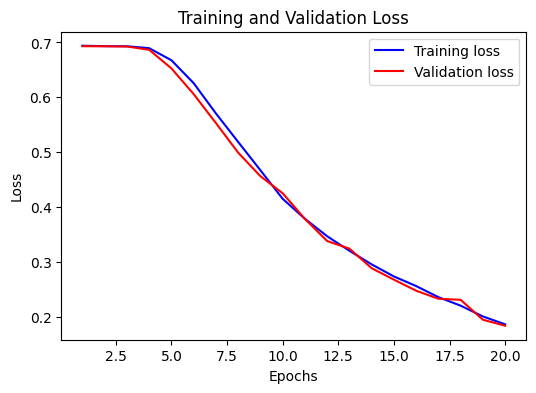

Training model: 2conv_64f_3x3_64f_3x3
Epoch 1/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.5002 - loss: 0.6944 - val_accuracy: 0.5000 - val_loss: 0.6943
Epoch 2/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.4922 - loss: 0.6938 - val_accuracy: 0.5077 - val_loss: 0.6930
Epoch 3/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.5133 - loss: 0.6929 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 4/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.5007 - loss: 0.6932 - val_accuracy: 0.5001 - val_loss: 0.6932
Epoch 5/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.4996 - loss: 0.6931 - val_accuracy: 0.5302 - val_loss: 0.6908
Epoch 6/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.5473 - loss: 0.6872 - val_accuracy: 0.5307 - val_loss: 0.6887
Epoch 7/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.5834 - loss: 0.6750 - val_accuracy: 0.6148 - val_loss: 0.6578
Epoch 8/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accu

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 28, 28, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │       200,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 715,205 (2.73 MB)

 Trainable params: 238,401 (931.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 476,804 (1.82 MB)

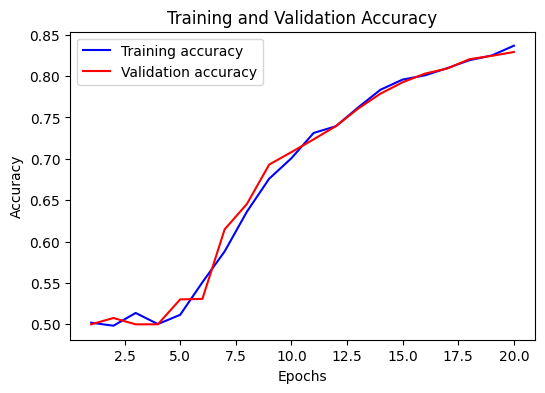

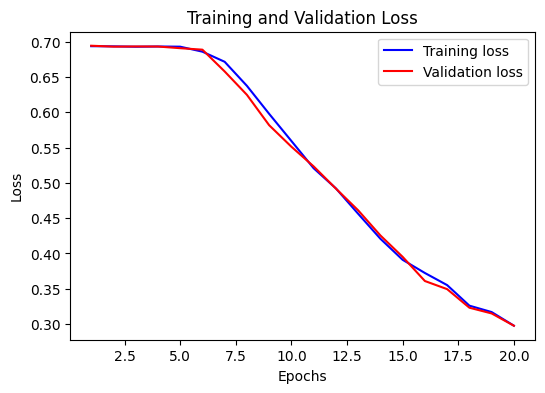


Experiment Results (Final Validation Accuracy and Parameter Count):
1conv_16f_7x7: Params = 201,633 | Final Validation Accuracy = 0.6104
1conv_16f_5x5: Params = 201,249 | Final Validation Accuracy = 0.5413
1conv_16f_3x3: Params = 200,993 | Final Validation Accuracy = 0.5477
2conv_16f_3x3_16f_3x3: Params = 52,785 | Final Validation Accuracy = 0.7846
2conv_16f_3x3_32f_3x3: Params = 105,281 | Final Validation Accuracy = 0.8089
2conv_32f_3x3_32f_3x3: Params = 110,049 | Final Validation Accuracy = 0.7982
2conv_32f_3x3_64f_3x3: Params = 219,649 | Final Validation Accuracy = 0.9180
2conv_64f_3x3_64f_3x3: Params = 238,401 | Final Validation Accuracy = 0.8292


In [6]:
# Given the relatively small size of the dataset, we set the number of epochs to 20 
# to ensure the model has enough time to learn the patterns in the data.
histories = {}
saved_models = {}

for config in cnn_model_configs:
    # Build the model of the current config
    model_name = config['name']
    model = build_model_from_config(config)

    print(f"Training model: {model_name}")
    # Compile to reset optimizer state before training
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

    # Train the model for 20 epochs for experiements with batch size 64
    history = model.fit(
        train_ds,
        epochs=20,
        batch_size=64,
        validation_data=val_ds
    )

    # Save the training history and the model
    histories[model_name] = history
    saved_models[model_name] = model
    print(f"Model: {model_name}")
    model.summary()
    plot_history(history)

# Report the overall experiment results
print("\nExperiment Results (Final Validation Accuracy and Parameter Count):")
for model_name, history in histories.items():
    val_acc = history.history['val_accuracy'][-1]
    param_count = saved_models[model_name].count_params()
    print(f"{model_name}: Params = {param_count:,} | Final Validation Accuracy = {val_acc:.4f}")


In [7]:
# Print out the parameter number as well before the accuracy
print("\nExperiment Results (Final Validation Accuracy and Parameter Count):")
for model_name, history in histories.items():
    val_acc = history.history['val_accuracy'][-1]
    # Get parameter count from the model
    param_count = saved_models[model_name].count_params()
    print(f"{model_name}: Params = {param_count:,} | Final Validation Accuracy = {val_acc:.4f}")



Experiment Results (Final Validation Accuracy and Parameter Count):
1conv_16f_7x7: Params = 201,633 | Final Validation Accuracy = 0.6104
1conv_16f_5x5: Params = 201,249 | Final Validation Accuracy = 0.5413
1conv_16f_3x3: Params = 200,993 | Final Validation Accuracy = 0.5477
2conv_16f_3x3_16f_3x3: Params = 52,785 | Final Validation Accuracy = 0.7846
2conv_16f_3x3_32f_3x3: Params = 105,281 | Final Validation Accuracy = 0.8089
2conv_32f_3x3_32f_3x3: Params = 110,049 | Final Validation Accuracy = 0.7982
2conv_32f_3x3_64f_3x3: Params = 219,649 | Final Validation Accuracy = 0.9180
2conv_64f_3x3_64f_3x3: Params = 238,401 | Final Validation Accuracy = 0.8292


##### 2.1.1.3 Plot Model Experiment Performances

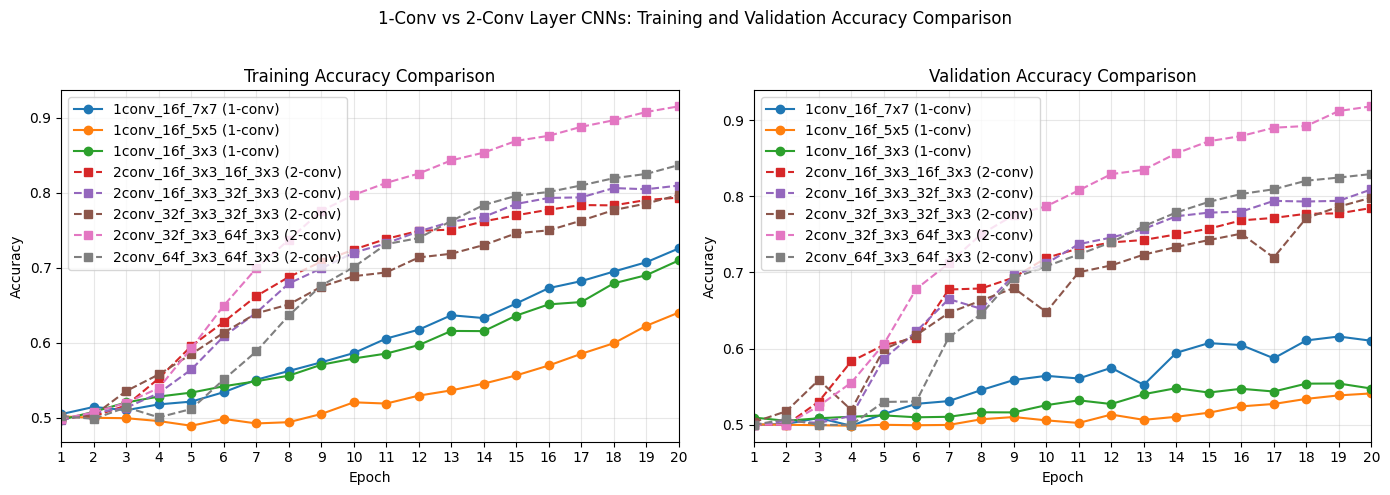

In [8]:
 # Identify 1-conv and 2-conv models by their names
one_conv_names = [name for name in histories if name.startswith('1conv')]
two_conv_names = [name for name in histories if name.startswith('2conv')]

plt.figure(figsize=(14, 5))

# Set up the number of epochs for experiments
n_epochs = 20
epochs = list(range(1, n_epochs + 1))  # Now epochs are 1-based: [1, 2, ..., 20]

# First plot: Training accuracy only, overlay all models, distinguish by 1-layer/2-layer
plt.subplot(1, 2, 1)
for name in one_conv_names:
    plt.plot(epochs, histories[name].history['accuracy'], label=f"{name} (1-conv)", linestyle='-', marker='o')
for name in two_conv_names:
    plt.plot(epochs, histories[name].history['accuracy'], label=f"{name} (2-conv)", linestyle='--', marker='s')
plt.title("Training Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xlim(1, n_epochs)
plt.xticks(epochs)
plt.legend()
plt.grid(True, alpha=0.3)

# Second plot: Validation accuracy only, overlay all models, distinguish by 1-layer/2-layer
plt.subplot(1, 2, 2)
for name in one_conv_names:
    plt.plot(epochs, histories[name].history['val_accuracy'], label=f"{name} (1-conv)", linestyle='-', marker='o')
for name in two_conv_names:
    plt.plot(epochs, histories[name].history['val_accuracy'], label=f"{name} (2-conv)", linestyle='--', marker='s')
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xlim(1, n_epochs)
plt.xticks(epochs)
plt.legend()
plt.grid(True, alpha=0.3)

plt.suptitle("1-Conv vs 2-Conv Layer CNNs: Training and Validation Accuracy Comparison")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


#### 2.1.2 Second Experiement: Various Kernel Size (Based on 2_conv_32f_64f)

##### 2.1.2.1 Model Configurations

In [12]:
cnn_model_configs_second_experiement = [
    {
        "name": "2conv_32f_5x5_64f_3x3",
        "conv_layers": [
            {"filters": 32, "kernel_size": (5, 5)},
            {"filters": 64, "kernel_size": (3, 3)}
        ],
        # 32->64 filters, 5x5 then 3x3 kernels
        # Intuition: This model uses a larger kernel size in the first layer to capture more global features,
        # followed by a smaller kernel size in the second layer for more detailed local features.
    },
    {
        "name": "2conv_32f_7x7_64f_5x5",
        "conv_layers": [
            {"filters": 32, "kernel_size": (7, 7)},
            {"filters": 64, "kernel_size": (5, 5)}
        ],
        # 32->64 filters, 7x7 then 5x5 kernels
        # Intuition: This model uses a even larger kernel size in the first layer to capture more global features,
        # followed by a medium kernel size in the second layer for more detailed local features.
        # This model is more complex and want to test whether the model can handle larger kernel size.
    },
    {
        "name": "2conv_32f_7x7_64f_3x3",
        "conv_layers": [
            {"filters": 32, "kernel_size": (7, 7)},
            {"filters": 64, "kernel_size": (3, 3)}
        ],
        # 32->64 filters, 7x7 then 3x3 kernels
        # Intuition: This model uses a aggresive kernel size in the first layer to capture more global features,
        # followed by a small kernel size in the second layer for more detailed local features.
        # This model is slighly less complex compared to the previous model.
    }
]


##### 2.1.2.2 Model Trainning for Experiements

Training model: 2conv_32f_5x5_64f_3x3
Epoch 1/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.5085 - loss: 0.6941 - val_accuracy: 0.5030 - val_loss: 0.6931
Epoch 2/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.5043 - loss: 0.6932 - val_accuracy: 0.5044 - val_loss: 0.6931
Epoch 3/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.4906 - loss: 0.6934 - val_accuracy: 0.5064 - val_loss: 0.6931
Epoch 4/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.5017 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6965
Epoch 5/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.5104 - loss: 0.6929 - val_accuracy: 0.5023 - val_loss: 0.6908
Epoch 6/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.5717 - loss: 0.6748 - val_accuracy: 0.6361 - val_loss: 0.6447
Epoch 7/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.6445 - loss: 0.6224 - val_accuracy: 0.7057 - val_loss: 0.5697
Epoch 8/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accu

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 28, 28, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │       200,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 660,485 (2.52 MB)

 Trainable params: 220,161 (860.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 440,324 (1.68 MB)

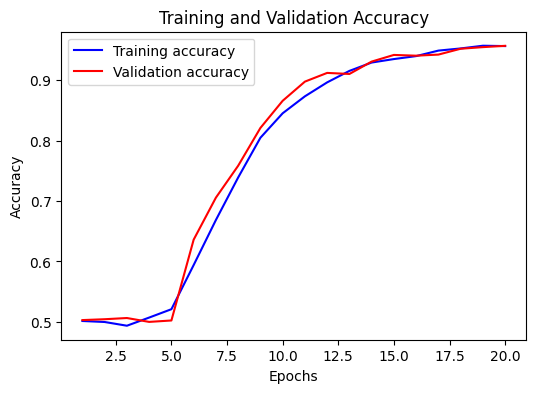

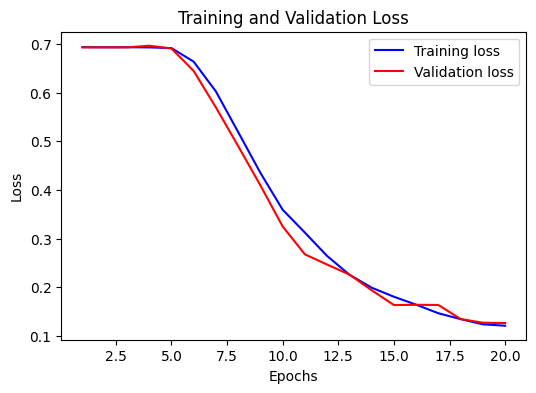

Training model: 2conv_32f_7x7_64f_5x5
Epoch 1/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.4920 - loss: 0.6946 - val_accuracy: 0.5061 - val_loss: 0.6931
Epoch 2/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.5046 - loss: 0.6932 - val_accuracy: 0.5136 - val_loss: 0.6931
Epoch 3/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.4929 - loss: 0.6932 - val_accuracy: 0.5148 - val_loss: 0.6929
Epoch 4/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.5082 - loss: 0.6930 - val_accuracy: 0.5000 - val_loss: 0.6965
Epoch 5/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.5219 - loss: 0.6918 - val_accuracy: 0.5460 - val_loss: 0.6821
Epoch 6/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.5699 - loss: 0.6726 - val_accuracy: 0.5836 - val_loss: 0.6744
Epoch 7/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.6379 - loss: 0.6200 - val_accuracy: 0.7377 - val_loss: 0.5186
Epoch 8/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accu

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 28, 28, 32)     │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 14, 14, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 64)             │       200,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 761,093 (2.90 MB)

 Trainable params: 253,697 (991.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 507,396 (1.94 MB)

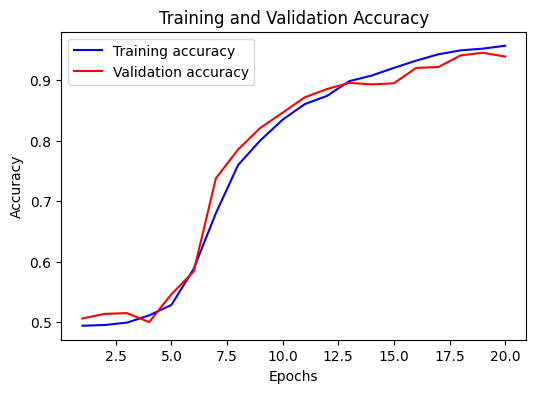

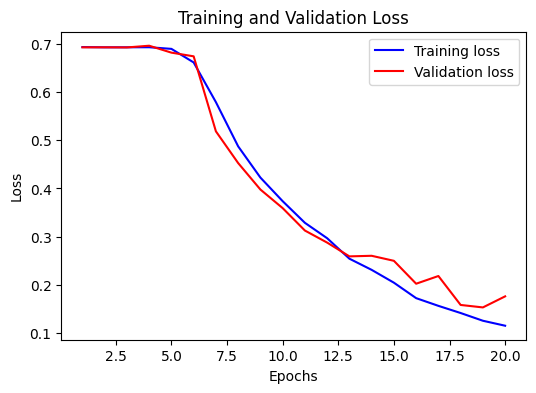

Training model: 2conv_32f_7x7_64f_3x3
Epoch 1/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.4981 - loss: 0.6954 - val_accuracy: 0.5017 - val_loss: 0.6931
Epoch 2/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.4975 - loss: 0.6933 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 3/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.5061 - loss: 0.6934 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 4/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.4944 - loss: 0.6933 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 5/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.5051 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 6/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.4945 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 7/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.4902 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 8/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accu

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 28, 28, 32)     │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_11 (Flatten)            │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 64)             │       200,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 662,789 (2.53 MB)

 Trainable params: 220,929 (863.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 441,860 (1.69 MB)

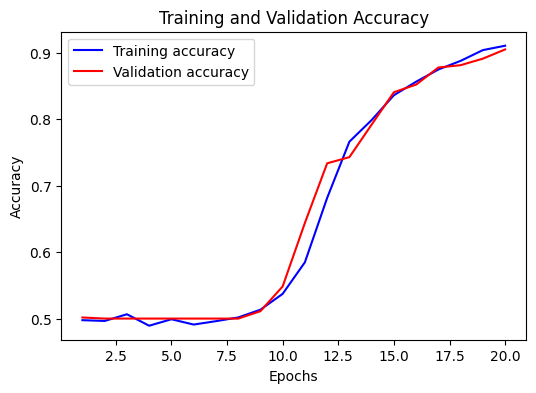

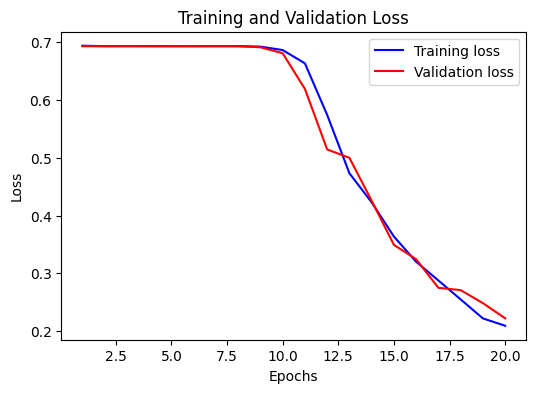

In [13]:
# Given the relatively small size of the dataset, we set the number of epochs to 20 
# to ensure the model has enough time to learn the patterns in the data.
second_histories = {}
for config in cnn_model_configs_second_experiement:
    print(f"Training model: {config['name']}")
    model = build_model_from_config(config)
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    history = model.fit(
        train_ds,
        epochs=20,
        batch_size=64,
        validation_data=val_ds,
        verbose=1
    )
    saved_models[config['name']] = model # save the model
    second_histories[config['name']] = history # save the training history
    print(f"Model: {config['name']}")
    model.summary()
    plot_history(history)



In [18]:
# Add the 32f_3x3_64_3x3 model from histories to second_histories for comparison
second_histories['2conv_32f_3x3_64f_3x3'] = histories['2conv_32f_3x3_64f_3x3']

# Print out the parameter number as well before the accuracy
print("\nSecond Experiment Results (Final Validation Accuracy and Parameter Count):")
for model_name, history in second_histories.items():
    val_acc = history.history['val_accuracy'][-1]
    # Get parameter count from the model
    param_count = saved_models[model_name].count_params()
    print(f"{model_name}: Params = {param_count:,} | Final Validation Accuracy = {val_acc:.4f}")



Second Experiment Results (Final Validation Accuracy and Parameter Count):
2conv_32f_5x5_64f_3x3: Params = 220,161 | Final Validation Accuracy = 0.9569
2conv_32f_7x7_64f_5x5: Params = 253,697 | Final Validation Accuracy = 0.9390
2conv_32f_7x7_64f_3x3: Params = 220,929 | Final Validation Accuracy = 0.9047
2conv_32f_3x3_64f_3x3: Params = 219,649 | Final Validation Accuracy = 0.9180


##### 2.1.2.3 Plot second experiement rsults

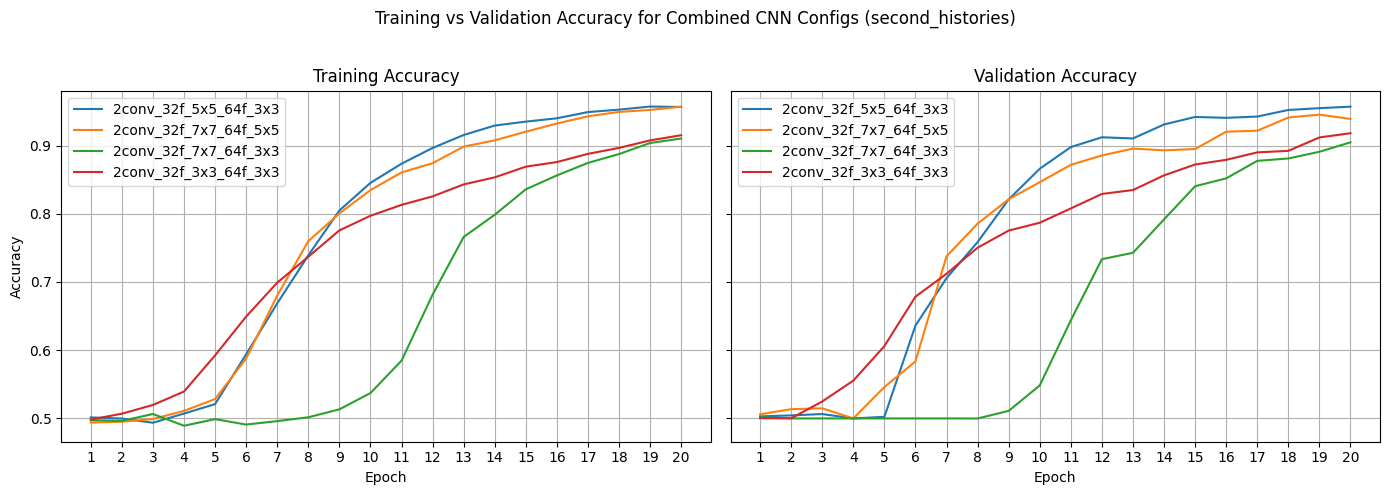

In [20]:
# Plot training and validation accuracy for the two new CNN configs side by side using second_histories

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)

for key, history in second_histories.items():
    axes[0].plot(range(1, len(history.history['accuracy']) + 1), history.history['accuracy'], label=f"{key}")
    axes[1].plot(range(1, len(history.history['val_accuracy']) + 1), history.history['val_accuracy'], label=f"{key}")



axes[0].set_title("Training Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].set_xticks(range(1, 21))
axes[0].legend()
axes[0].grid(True)

axes[1].set_title("Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_xticks(range(1, 21))
axes[1].legend()
axes[1].grid(True)

plt.suptitle("Training vs Validation Accuracy for Combined CNN Configs (second_histories)")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


#### 2.1.3 Final Experiement: Padding vs. No Padding

As we can see from the result, the 5 -> 3 kernels has the best performance. However, the default model setup uses `same` padding to avoid the border information loss. I want to test if no additional padding (`valid`) will have the similar performance, if so, we can create a even smaller model with less parameters.

##### 2.1.3.1 Setting up model with valid padding

Epoch 1/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.4907 - loss: 0.6961 - val_accuracy: 0.5011 - val_loss: 0.6931
Epoch 2/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.5045 - loss: 0.6937 - val_accuracy: 0.5049 - val_loss: 0.6931
Epoch 3/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.5038 - loss: 0.6932 - val_accuracy: 0.4999 - val_loss: 0.6931
Epoch 4/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.4978 - loss: 0.6932 - val_accuracy: 0.5002 - val_loss: 0.6931
Epoch 5/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.4947 - loss: 0.6933 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 6/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.5118 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6937
Epoch 7/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.4962 - loss: 0.6935 - val_accuracy: 0.5000 - val_loss: 0.6940
Epoch 8/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5146 - loss: 0.6933 - val_accuracy:

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 24, 24, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 10, 10, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_12 (Flatten)            │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 365,573 (1.39 MB)

 Trainable params: 121,857 (476.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 243,716 (952.02 KB)

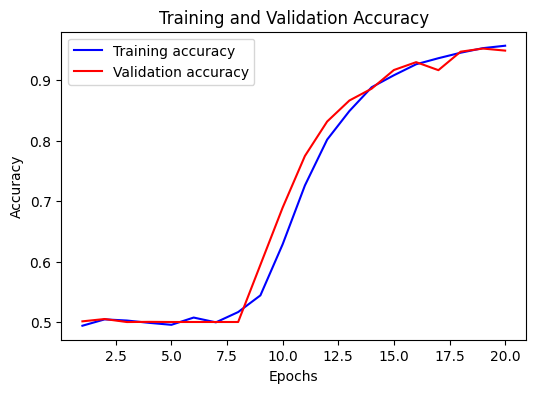

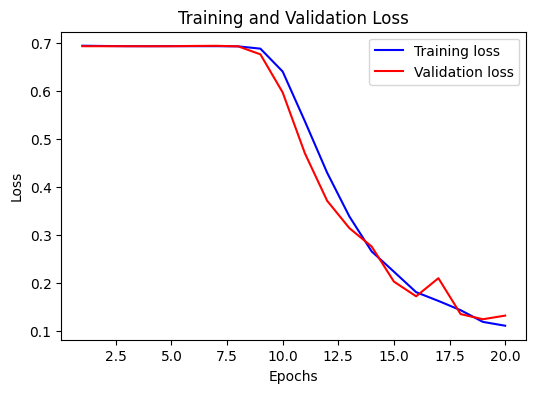

In [21]:
# Create a new model with 'valid' padding and same architecture as the best model
model_valid_padding = models.Sequential([
    # Input: 28x28 grayscale (1 channel)
    layers.Input(shape=(28, 28, 1)),

    # Apply augmentation only during training
    data_augmentation,

    # First Convolutional Layer with 'valid' padding
    layers.Conv2D(32, (5, 5), activation='relu', padding='valid'),
    layers.MaxPooling2D((2, 2)),

    # Second Convolutional Layer with 'valid' padding
    layers.Conv2D(64, (3, 3), activation='relu', padding='valid'),
    layers.MaxPooling2D((2, 2)),

    # Flatten and dense layers
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')  # Binary classification
])

# Compile model
model_valid_padding.compile(optimizer='adam',
                           loss='binary_crossentropy',
                           metrics=['accuracy'])

history_valid_padding = model_valid_padding.fit(
    train_ds,
    epochs=20,
    batch_size=64,
    validation_data=val_ds,
    verbose=1
)

# Show summary and plot history
model_valid_padding.summary()
plot_history(history_valid_padding)


##### 2.1.3.2 Comparison between valid and same padding

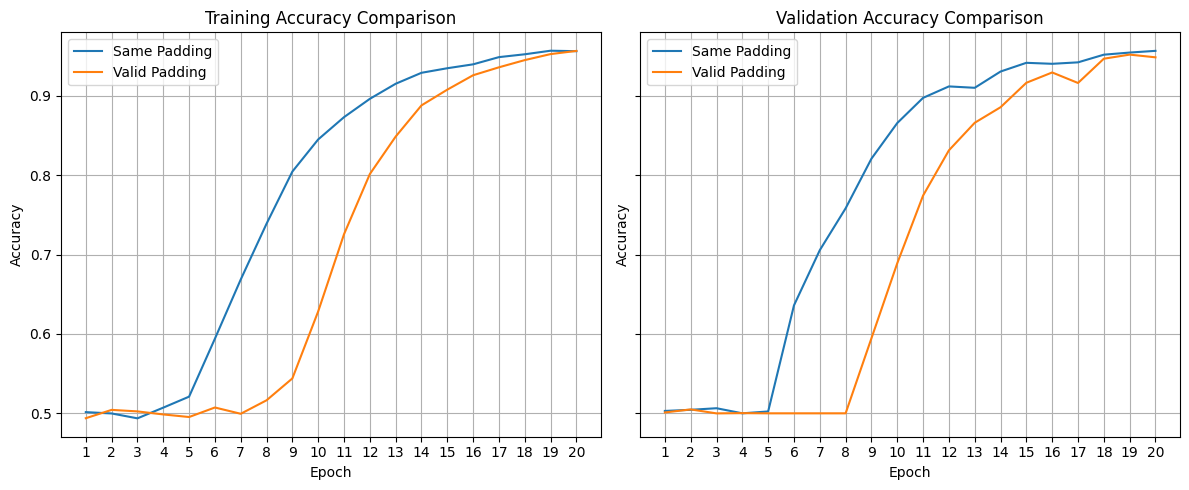

Same Padding Model - Final Validation Accuracy: 0.9569, Parameters: 220161
Valid Padding Model - Final Validation Accuracy: 0.9488, Parameters: 121857


In [22]:
# Get the histories and of the same padding model for comparison
history_same_padding = second_histories['2conv_32f_5x5_64f_3x3']
model_same_padding = saved_models['2conv_32f_5x5_64f_3x3']

# Create side-by-side comparison plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

# Plot training accuracy comparison
axes[0].plot(range(1, len(history_same_padding.history['accuracy']) + 1), history_same_padding.history['accuracy'], label='Same Padding')
axes[0].plot(range(1, len(history_valid_padding.history['accuracy']) + 1), history_valid_padding.history['accuracy'], label='Valid Padding')
axes[0].set_title('Training Accuracy Comparison')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_xticks(range(1, 21))  # Set epoch ticks from 1 to 20
axes[0].legend()
axes[0].grid(True)

# Plot validation accuracy comparison
axes[1].plot(range(1, len(history_same_padding.history['val_accuracy']) + 1), history_same_padding.history['val_accuracy'], label='Same Padding')
axes[1].plot(range(1, len(history_valid_padding.history['val_accuracy']) + 1), history_valid_padding.history['val_accuracy'], label='Valid Padding')
axes[1].set_title('Validation Accuracy Comparison')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_xticks(range(1, 21))  # Set epoch ticks from 1 to 20
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Calculate and display final performance metrics
final_acc_same = history_same_padding.history['val_accuracy'][-1]
final_acc_valid = history_valid_padding.history['val_accuracy'][-1]

print(f"Same Padding Model - Final Validation Accuracy: {final_acc_same:.4f}, Parameters: {model_same_padding.count_params()}")
print(f"Valid Padding Model - Final Validation Accuracy: {final_acc_valid:.4f}, Parameters: {model_valid_padding.count_params()}")


### 2.2 Final Model Selection

For the final model, I selected two convolutional layers with kernel sizes of 5x5 and 3x3, with 32 filters in first convolution layer and 64 filters in second convolution layer. I set the padding to 'valid' (zero padding) and added a dropout layer to prevent overfitting. To ensure the model converges to stable performance, I set the training epochs to 30.

Epoch 1/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.5005 - loss: 0.6948 - val_accuracy: 0.5000 - val_loss: 0.6936
Epoch 2/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.5017 - loss: 0.6934 - val_accuracy: 0.5011 - val_loss: 0.6930
Epoch 3/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5155 - loss: 0.6929 - val_accuracy: 0.5000 - val_loss: 0.6952
Epoch 4/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5437 - loss: 0.6876 - val_accuracy: 0.5898 - val_loss: 0.6714
Epoch 5/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.6123 - loss: 0.6571 - val_accuracy: 0.6585 - val_loss: 0.6155
Epoch 6/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6796 - loss: 0.5937 - val_accuracy: 0.7281 - val_loss: 0.5378
Epoch 7/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7435 - loss: 0.5099 - val_accuracy: 0.7896 - val_loss: 0.4333
Epoch 8/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7984 - loss: 0.4210 - val_accuracy: 0.

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 24, 24, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 10, 10, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_13 (Flatten)            │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 365,573 (1.39 MB)

 Trainable params: 121,857 (476.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 243,716 (952.02 KB)

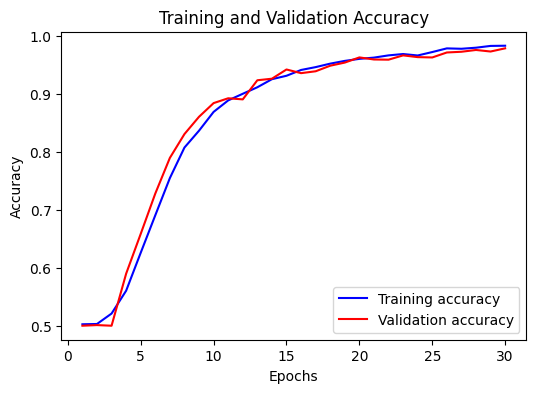

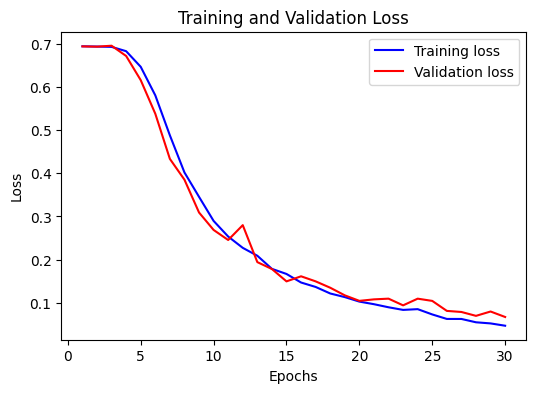

In [23]:
# Define the final model
final_model = models.Sequential([
    # Input: 28x28 grayscale (1 channel)
    layers.Input(shape=(28, 28, 1)),

    # Apply augmentation only during training
    data_augmentation,

    # Convolutional layers should be added here
    # First Convolutional Layer
    layers.Conv2D(32, (5, 5), activation='relu', padding='valid'),
    layers.MaxPooling2D((2, 2)),

    # Second Convolutional Layer
    layers.Conv2D(64, (3, 3), activation='relu', padding='valid'),
    layers.MaxPooling2D((2, 2)),

    # Flatten and dense layers
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2), # drop out rate is 0.2 to prevent overfitting
    layers.Dense(1, activation='sigmoid')  # Binary classification
])

# Compile model
final_model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

final_history = final_model.fit(
        train_ds,
        epochs=30,
        batch_size=64,
        validation_data=val_ds,
        verbose=1
    )

final_model.summary()
plot_history(final_history)

In [34]:
# Evaluate the final model on test data
test_loss, test_accuracy = final_model.evaluate(val_ds, verbose=0)
print(f"Final validation accuracy: {test_accuracy*100:.2f}%, Parameter count: {final_model.count_params()}")


Final validation accuracy: 97.86%, Parameter count: 121857


## 3. Kernel visualisation

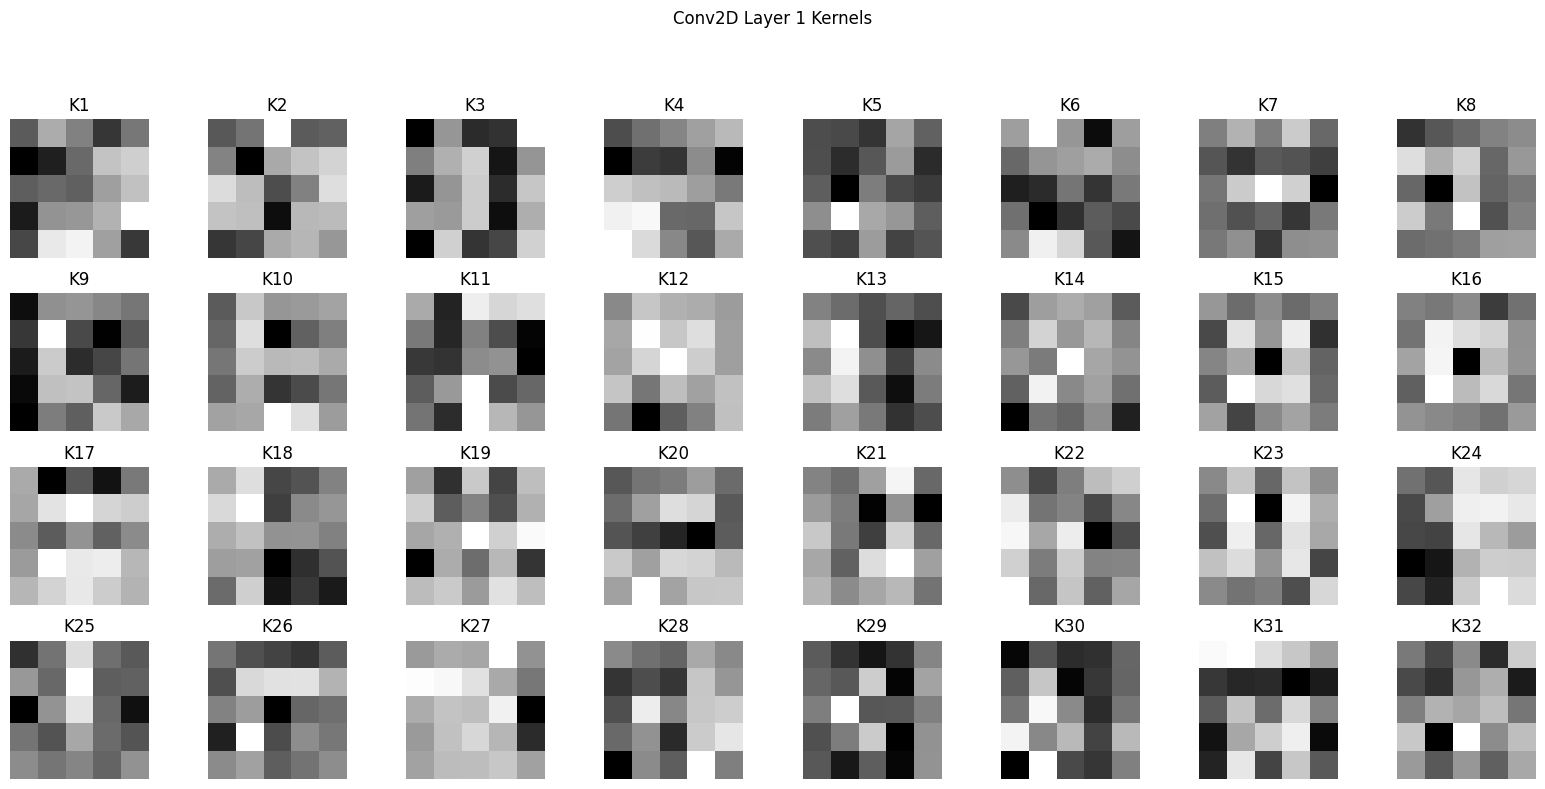

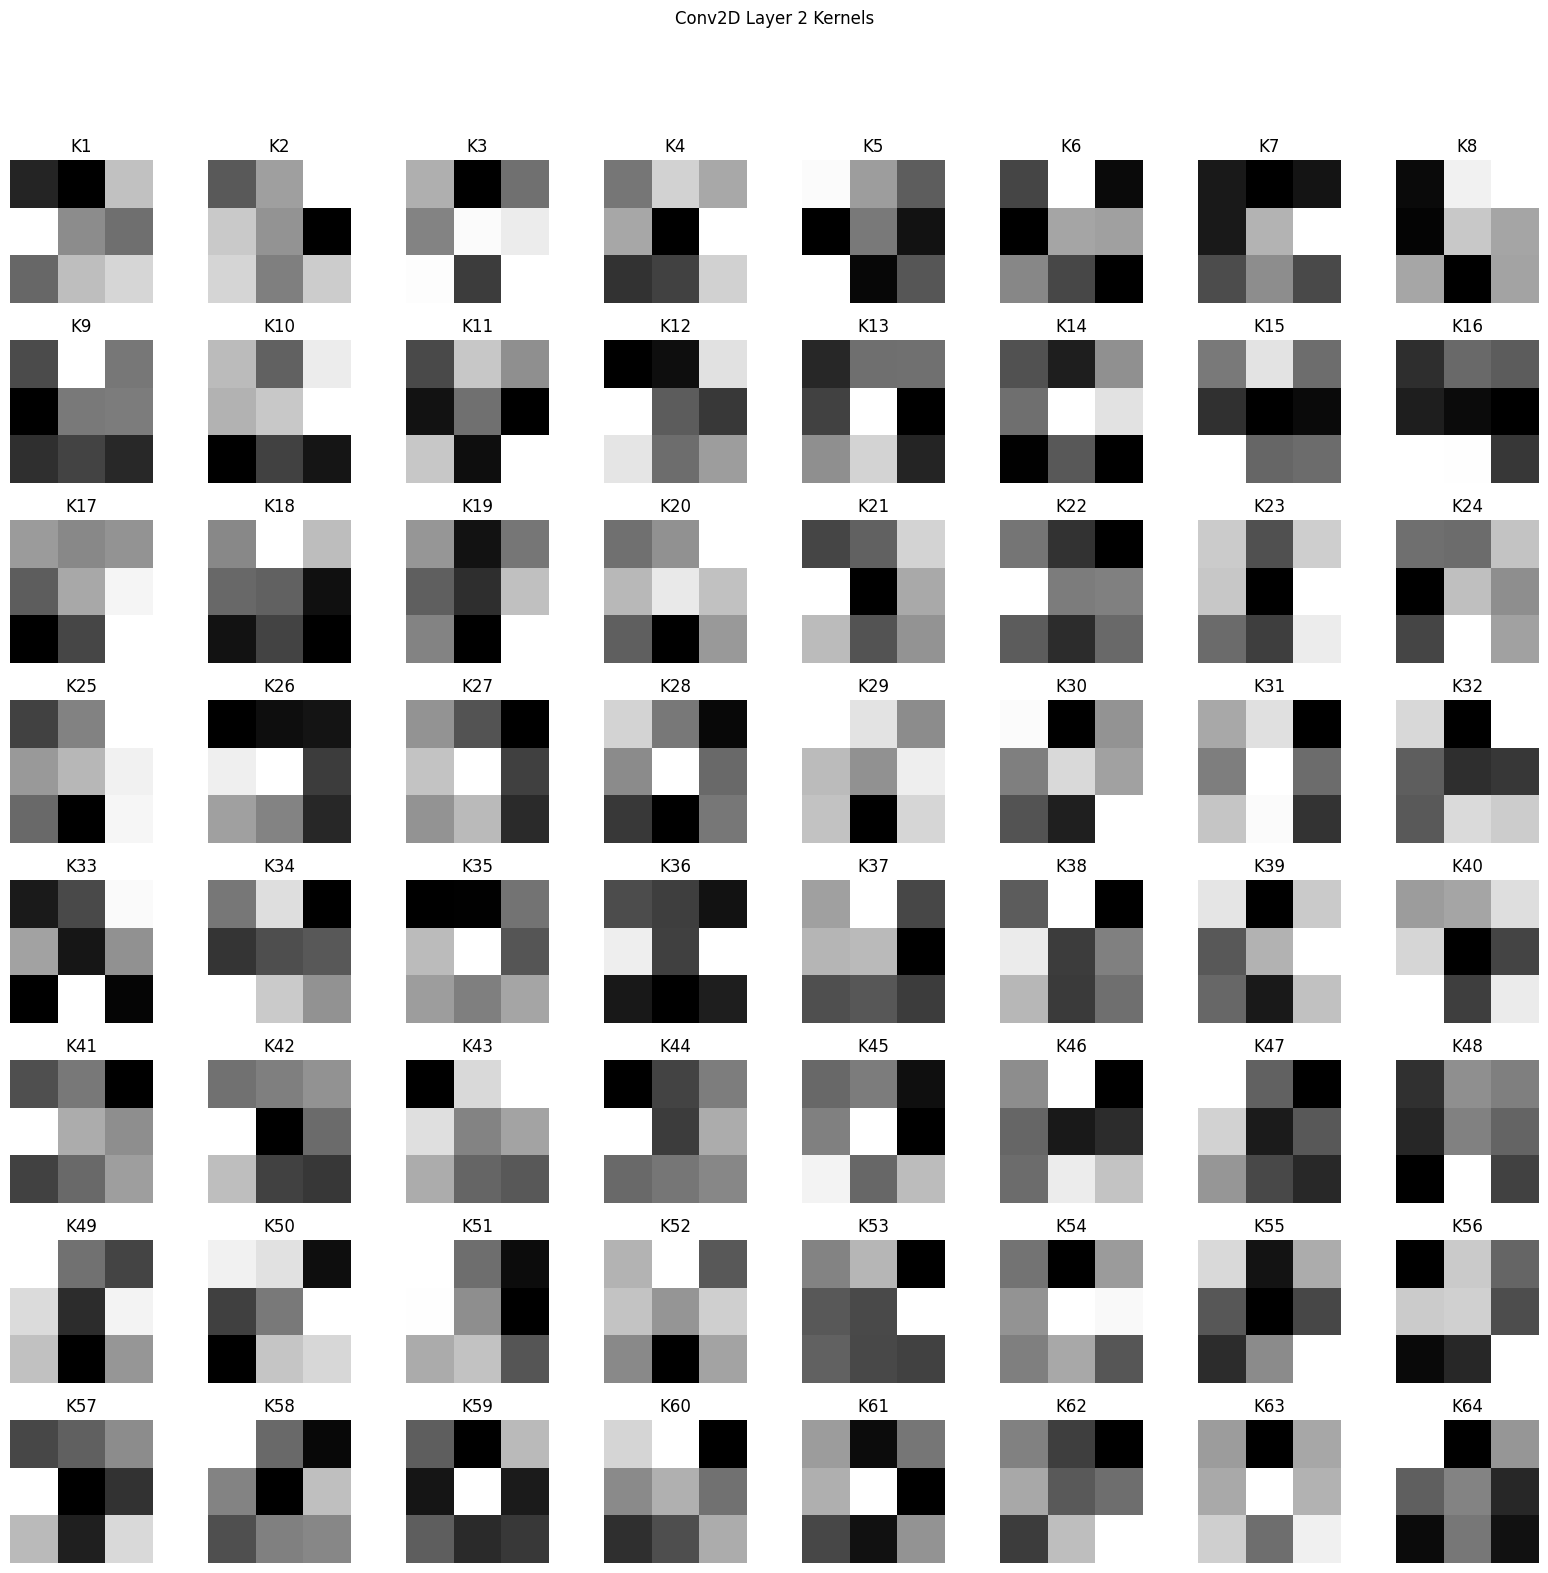

In [24]:
# Find the first and second Conv2D layers in the final_model
conv_layers = [layer for layer in final_model.layers if isinstance(layer, layers.Conv2D)]


# Visualize kernels for both Conv2D layers
for idx, conv_layer in enumerate(conv_layers[:2]):
    kernels, biases = conv_layer.get_weights()
    # Get the number of kernels in the current layer
    # the shape is like (kernel_size, kernel_size, input_channel, num_kernels)
    num_kernels = kernels.shape[-1]
    # Normalize kernels by min-max scaling for better visualisation
    kernels_min = kernels.min()
    kernels_max = kernels.max()
    # Add a small epsilon to avoid division by zero
    kernels_norm = (kernels - kernels_min) / (kernels_max - kernels_min + 1e-5)
    
    # Set up grid size
    n_cols = min(num_kernels, 8)
    n_rows = int(np.ceil(num_kernels / n_cols))
    plt.figure(figsize=(2*n_cols, 2*n_rows))
    for i in range(num_kernels):
        plt.subplot(n_rows, n_cols, i + 1)
        # Show only the first input channel (since input is single channel image)
        plt.imshow(kernels_norm[:, :, 0, i], cmap='gray')
        plt.axis('off')
        plt.title(f'K{i+1}')
    plt.suptitle(f'Conv2D Layer {idx+1} Kernels')
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()


## 4. Where is the model looking?

#### 4.1 Grad-CAM Implementation

In [25]:

def compute_gradcam(model: tf.keras.Model,
                              img_array: np.ndarray,
                              upsample_size=(28, 28)) -> np.ndarray:
    """
    Compute Grad-CAM heatmap using an optimized approach.
    
    Grad-CAM (Gradient-weighted Class Activation Mapping) generates a heatmap
    showing which parts of the input image are most important for the model's
    prediction by computing gradients of the target class with respect to the
    feature maps of the last convolutional layer.
    """
    # 1. Normalise input to (1, H, W, 1) format with values in [0,1]
    x = img_array
    # If the input is a 2D array, add channel and batch dimension to be (1, H, W, 1)
    if x.ndim == 2:
        x = x[..., None]  # First add a channel dimension if missing to be (H, W, 1)
    x = x.astype("float32")
    if x.max() > 1.0:
        x = x / 255.0  # Normalise from [0,255] to [0,1]
    x = x[None, ...]  # Add batch dimension to be (1, H, W, 1)

    # 2. Find the last Conv2D layer in the model
    # Backward iteration to find the deepest convolutional layer
    last_conv_layer = None
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            last_conv_layer = layer
            break
    if last_conv_layer is None:
        raise ValueError("No Conv2D layer found in the model.")


    # Ensure model is built with input shape to avoid "never been called" errors
    _ = model(x, training=False)

    # 3. Create first sub-model: input -> last conv layer output
    # This extracts feature maps from the last convolutional layer
    grad_model_1 = tf.keras.models.Model(
        [model.inputs], [last_conv_layer.output]
    )

    # 4. Create second sub-model: conv output -> final prediction
    # This chains all layers after the last conv layer to get predictions
    last_idx = model.layers.index(last_conv_layer) # Get the index of the last conv layer
    conv_out_shape = last_conv_layer.output.shape[1:]  # (h, w, c)

    # Create a new input tensor with the shape of the last conv layer output
    conv_input = tf.keras.Input(shape=conv_out_shape)
    t = conv_input
    # Go through all the layers after the last conv layer to get the final prediction
    for i in range(last_idx + 1, len(model.layers)):
        t = model.layers[i](t)
    # Create a new model that takes the last conv layer output and outputs the final prediction
    grad_model_2 = tf.keras.models.Model([conv_input], [t])

    # 5. Compute gradients and generate heatmap
    with tf.GradientTape() as tape:
        # Forward pass through first sub-model to get conv feature maps
        conv_outputs = grad_model_1(x)           # Shape: (1, h, w, c)
        tape.watch(conv_outputs)  # Watch conv outputs for gradient computation
        
        # Forward pass through second sub-model to get predictions
        preds = grad_model_2(conv_outputs)       # Shape: (1, 1) since it's a binary classification
        
        # Select appropriate loss based on model output type
        if preds.shape[-1] == 1:                 # Binary classification (sigmoid)
            loss = preds[:, 0]
        else:                                    # Multi-class (softmax)
            cls_idx = tf.argmax(preds[0])  # Get predicted class index
            loss = preds[:, cls_idx]  # Use prediction for that class

    # Compute gradients of loss w.r.t. conv feature maps
    grads = tape.gradient(loss, conv_outputs)             # Shape: (1, h, w, c)
    
    # Global average pooling of gradients across spatial dimensions
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))  # Shape: (c,)
    
    # Remove batch dimension from conv outputs
    conv_outputs = conv_outputs[0]                        # Shape: (h, w, c)
    
    # Weighted combination of feature maps and gradients
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)  # Shape: (h, w)

    # 6. Post-process heatmap
    # Apply ReLU to focus on positive contributions only (only keep the positive gradients)
    heatmap = tf.nn.relu(heatmap)
    
    # Normalise to [0, 1] range for better visualisation
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)
    
    # Upsample to target size using bilinear interpolation
    heatmap = tf.image.resize(heatmap[..., tf.newaxis],
                              upsample_size, method='bilinear')[..., 0]
    
    return tf.squeeze(heatmap).numpy()


#### 4.2 Grad-CAM Visualisation

In [26]:
def plot_samples_with_gradcam_grid(
    model: tf.keras.Model,
    samples: list,
    class_name: str,
    predictions: list = None,
    true_labels: list = None,
    threshold: float = 0.5,
):
    """
    Visualise multiple samples with Grad-CAM heatmaps in a dynamic grid.
    Each row shows 2 samples (input + overlay for each), so 4 images per row.
    """
    num_samples = len(samples)
    # Each sample needs 2 subplots (input + overlay), so 4 images per row
    images_per_row = 4
    nrows = num_samples // 2
    
    # Create figure set up
    fig, axes = plt.subplots(nrows, images_per_row, figsize=(16, 4 * nrows))
    fig.suptitle(f"Grad-CAM Visualisation for Class: '{class_name}'", fontsize=18, y=0.95)
    
    # Handle case where we have only one row
    if nrows == 1:
        axes = axes.reshape(1, -1)
    
    # Flatten axes for easier indexing
    axes_flat = axes.flatten()

    for i, img in enumerate(samples):
        # Grad-CAM heatmap
        heatmap = compute_gradcam(model, img, upsample_size=(28, 28))

        # Base image
        base = img.squeeze()
        if base.max() > 1.0:
            base = base / 255.0
        # Convert heatmap to RGB
        hm_rgb = plt.cm.jet(heatmap)[..., :3]
        # Overlay the heatmap on the base image
        overlay = 0.6 * np.stack([base, base, base], axis=-1) + 0.4 * hm_rgb
        # Clip the overlay to the range [0, 1]
        overlay = np.clip(overlay, 0, 1)

        # Compose prediction text with correctness
        pred_text = ""
        correct_flag = ""
        color_ok = None
        if predictions is not None and i < len(predictions):
            p = float(predictions[i])
            pred_label = 1 if p >= threshold else 0
            pred_text = f"Pred: {pred_label} ({p:.3f})"
            if true_labels is not None and i < len(true_labels):
                t = int(true_labels[i]) if not isinstance(true_labels[i], (list, np.ndarray)) else int(true_labels[i][0])
                is_correct = (pred_label == t)
                correct_flag = " ✓" if is_correct else " ✗"
                color_ok = "green" if is_correct else "red"

        # Calculate subplot indices for side-by-side layout
        # Each sample takes 2 consecutive positions
        left_idx = i * 2
        right_idx = left_idx + 1

        # Plot input image
        axes_flat[left_idx].imshow(img.squeeze(), cmap='gray')
        axes_flat[left_idx].set_title(f"Sample {i+1} - Input", fontsize=14, fontweight='bold')
        axes_flat[left_idx].axis('off')

        # Plot overlay with prediction
        axes_flat[right_idx].imshow(overlay)
        title_text = f"Sample {i+1} - Grad-CAM\n{pred_text}{correct_flag}".strip()
        axes_flat[right_idx].set_title(title_text, color=color_ok, fontsize=14, fontweight='bold')
        axes_flat[right_idx].axis('off')

    # Hide unused subplots
    for i in range(num_samples * 2, len(axes_flat)):
        axes_flat[i].axis('off')

    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.show()


2025-09-12 18:10:09.693608: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


Collected 10 'L' samples and 10 'T' samples for Grad-CAM visualisation.


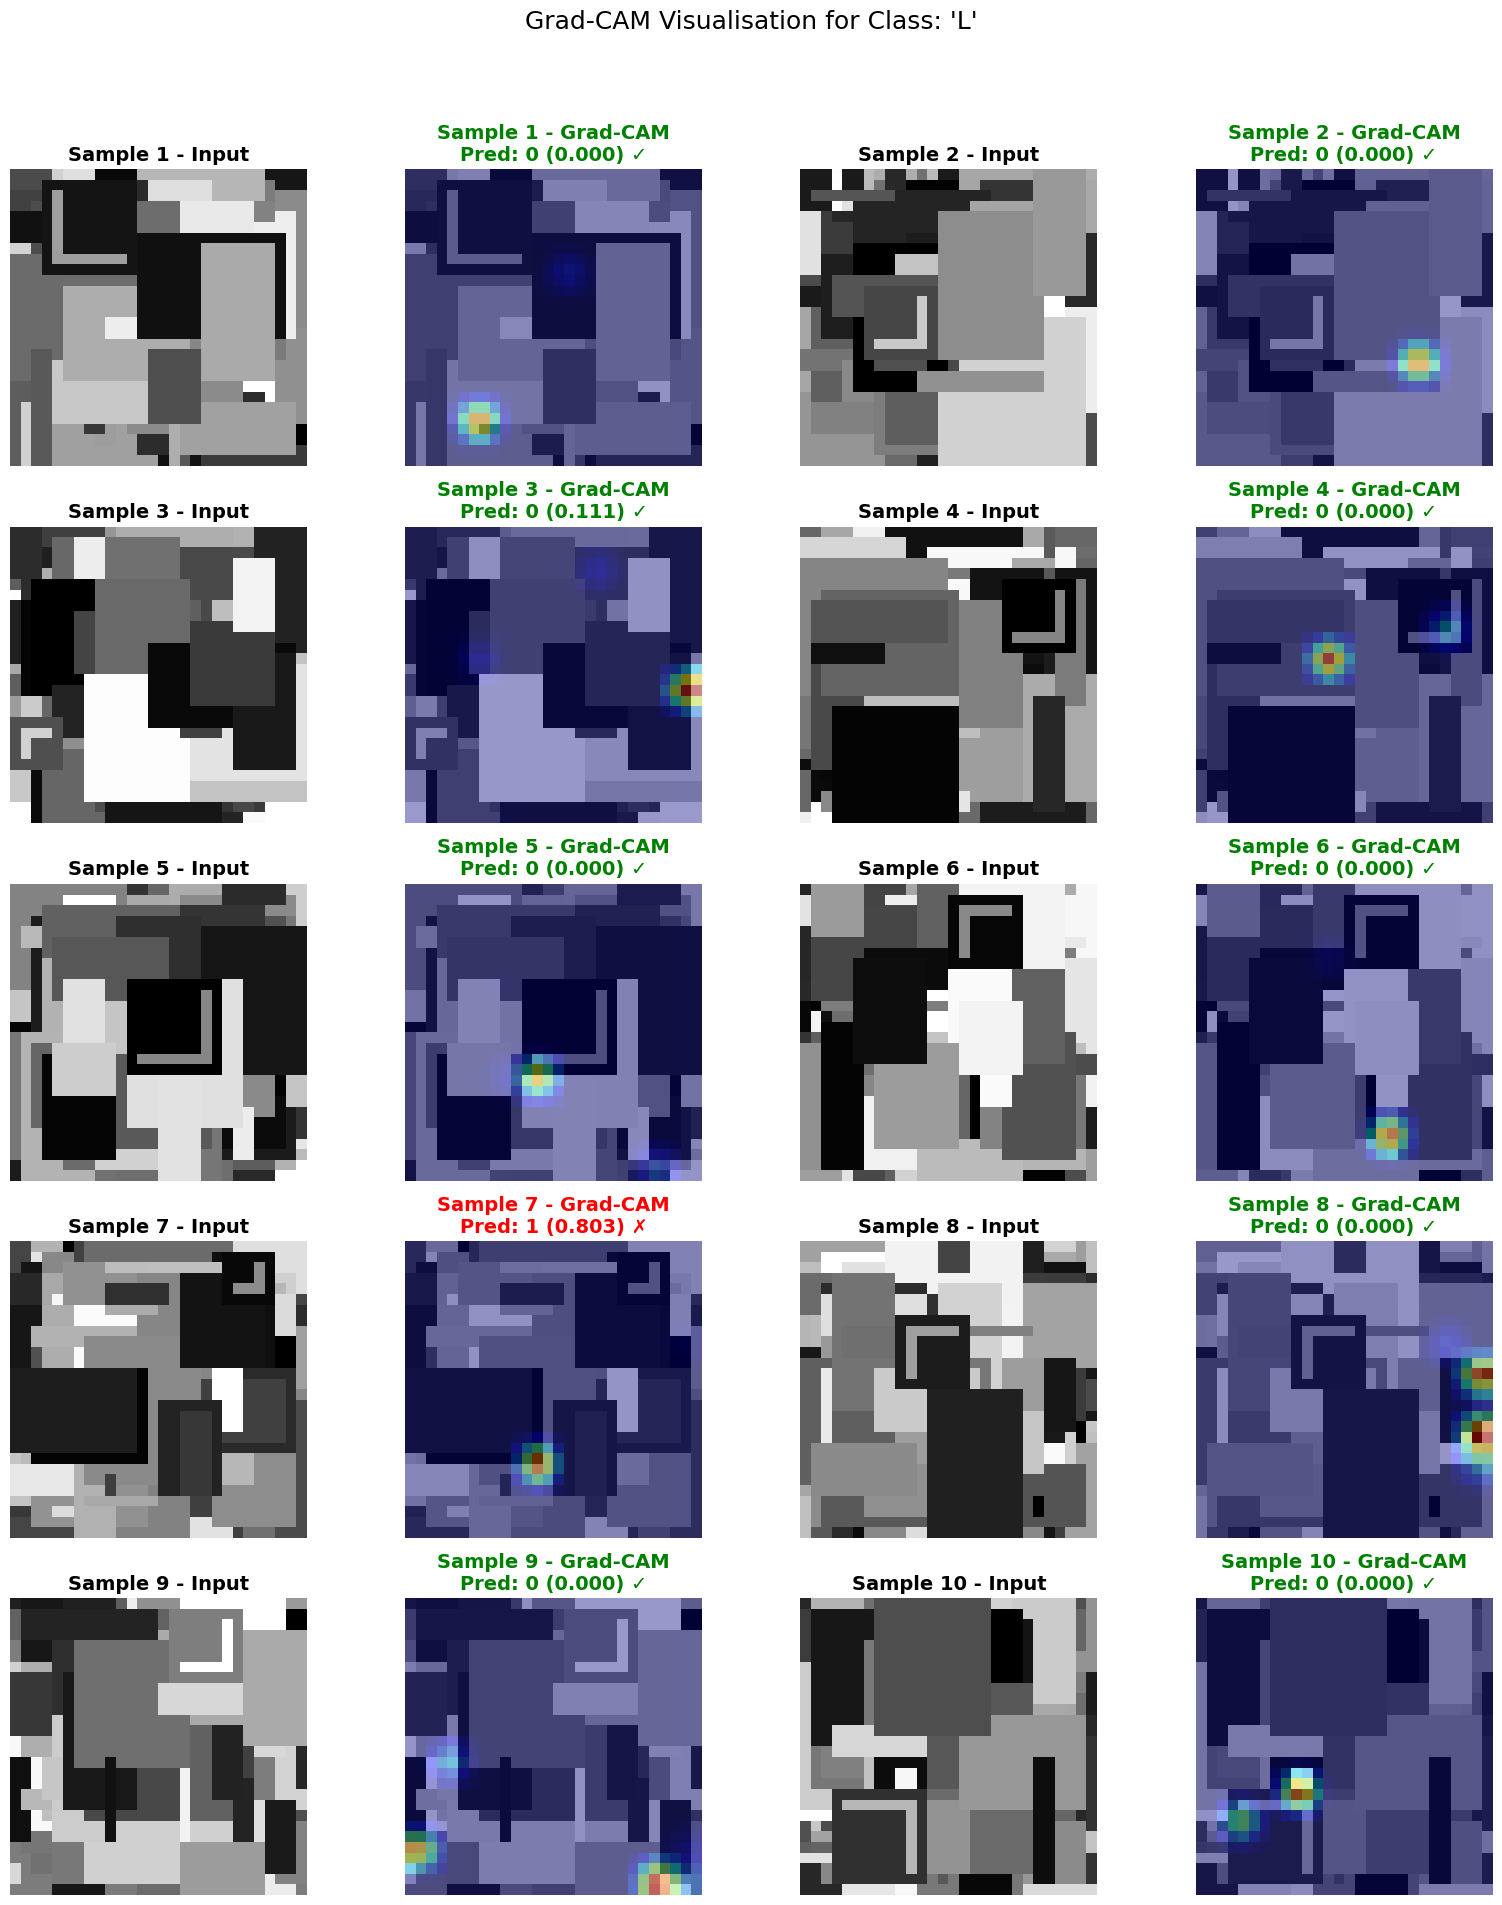

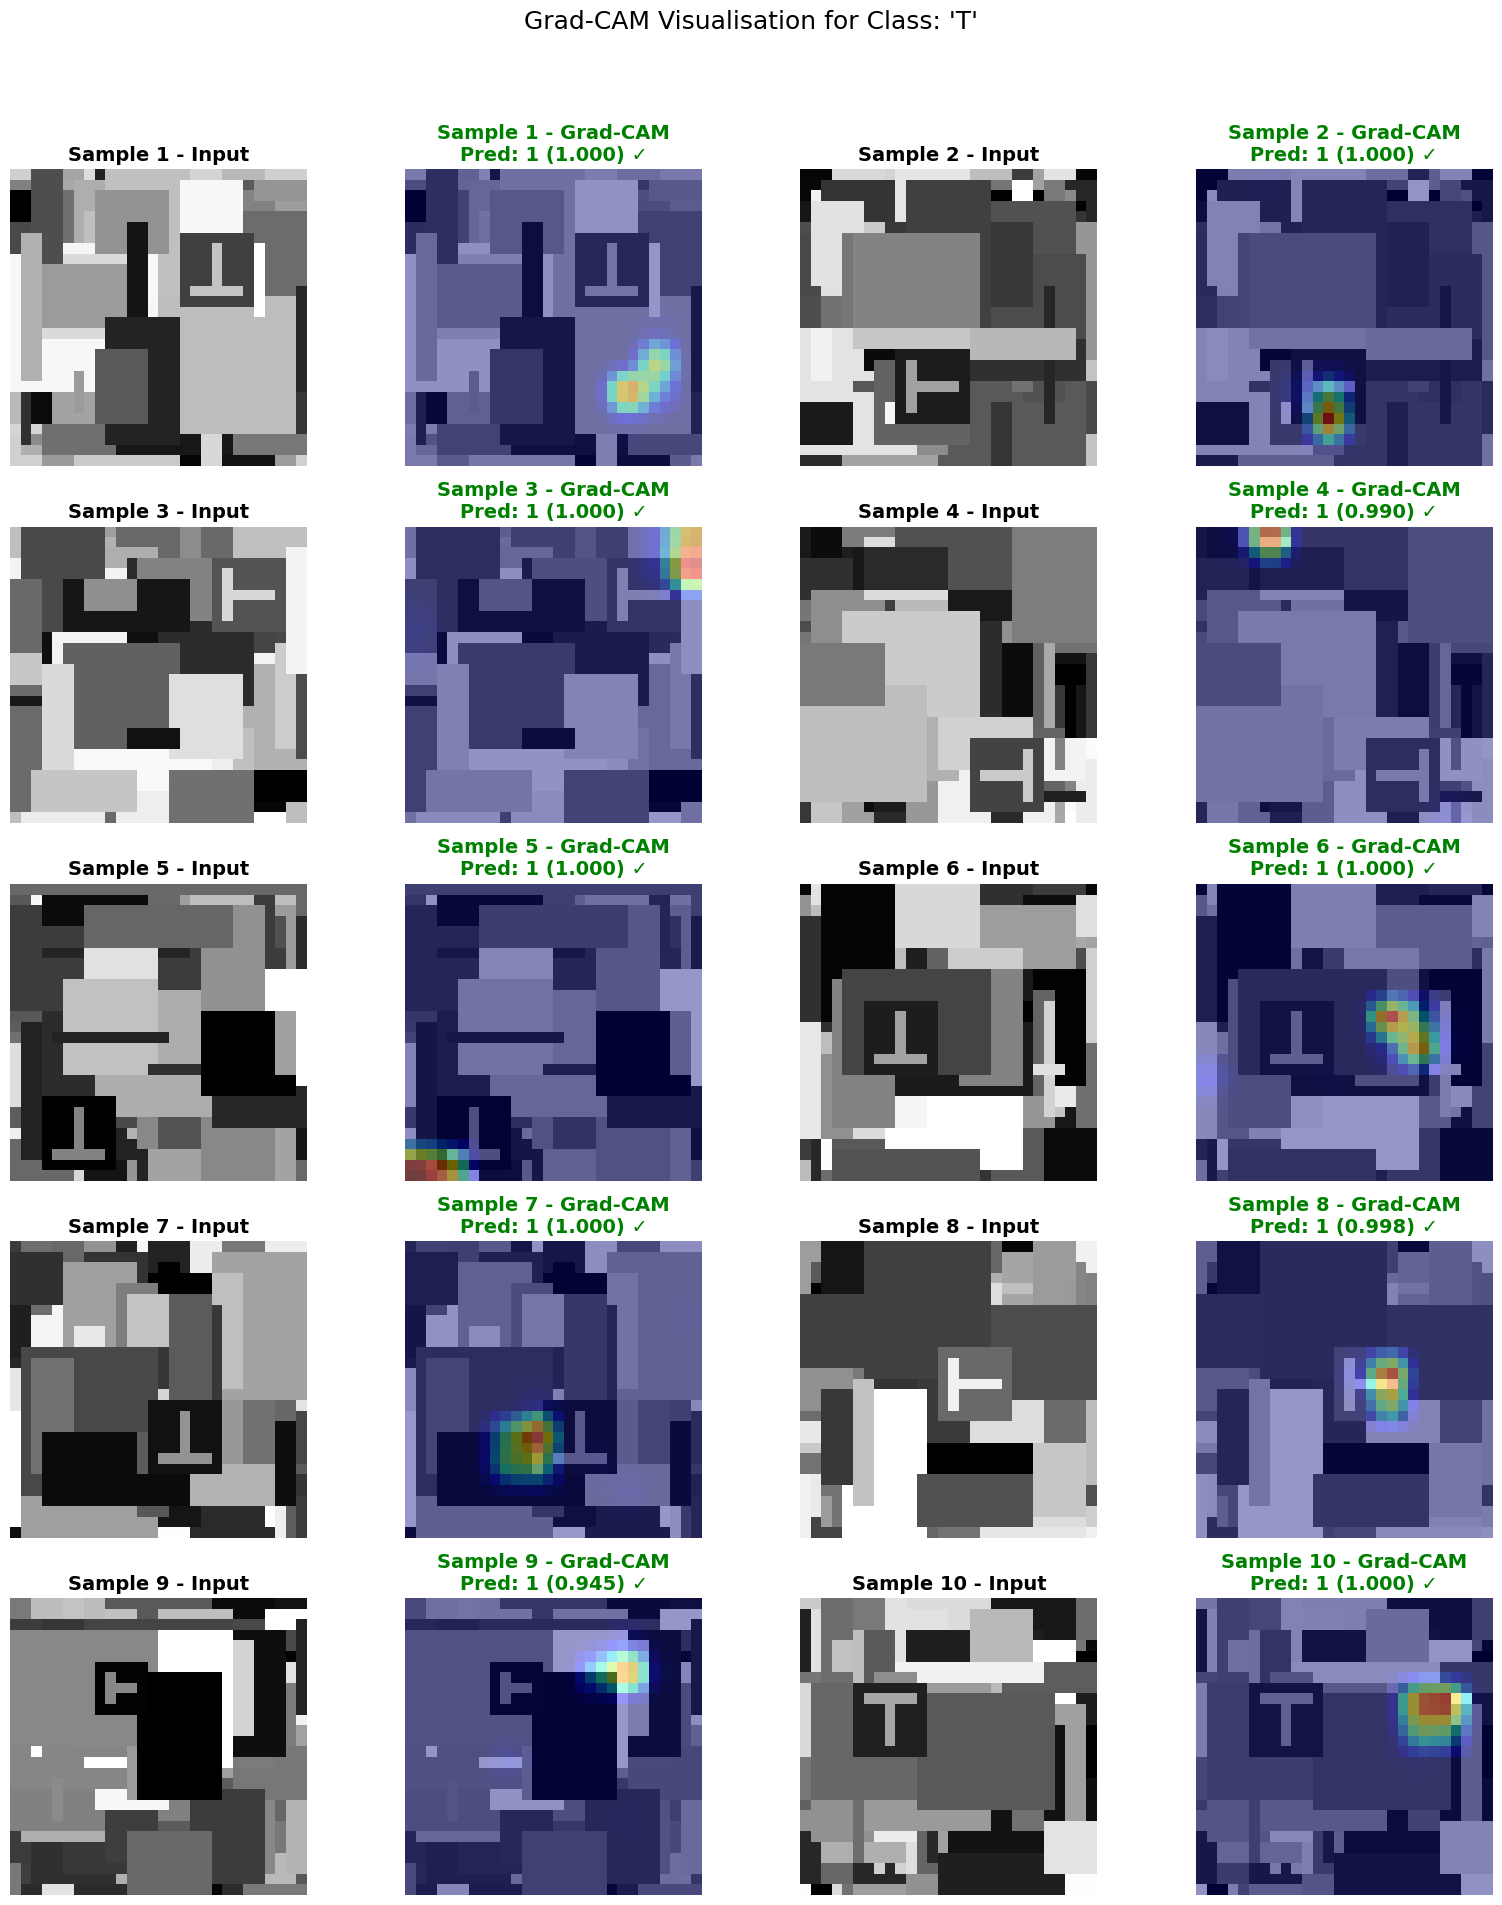

In [31]:
# Collect sample images from validation set for each class to generate Grad-CAM visualizations
num_examples_to_show = 10
samples_L, samples_T = [], []
labels_L, labels_T = [], []
predictions_L, predictions_T = [], []

THRESHOLD = 0.5  # sigmoid threshold for class label - standard threshold for binary classification

# Extract samples from the dataset safely 
# Take 20000 samples from the dataset and shuffle them
for images, labels in val_ds.unbatch().take(20000).shuffle(10000):  # .unbatch() allows us to process samples individually
    label = int(labels.numpy().item()) # Convert the label to an integer
    img_np = images.numpy() # Convert the image to a numpy array

    if label == 0 and len(samples_L) < num_examples_to_show:
        samples_L.append(img_np)
        labels_L.append(label)
        # Get model prediction for this sample
        pred = float(final_model.predict(img_np.reshape(1, 28, 28, 1), verbose=0)[0][0])
        predictions_L.append(pred)
    elif label == 1 and len(samples_T) < num_examples_to_show:
        samples_T.append(img_np)
        labels_T.append(label)
        # Get model prediction for this sample
        pred = float(final_model.predict(img_np.reshape(1, 28, 28, 1), verbose=0)[0][0])
        predictions_T.append(pred)

    if len(samples_L) == num_examples_to_show and len(samples_T) == num_examples_to_show:
        break

print(f"Collected {len(samples_L)} 'L' samples and {len(samples_T)} 'T' samples for Grad-CAM visualisation.")


# Visualise 'L' class samples with Grad-CAM heatmaps (with predictions/labels)
plot_samples_with_gradcam_grid(
    final_model, samples_L, class_name='L', 
    predictions=predictions_L, true_labels=labels_L, threshold=THRESHOLD
)

# Visualise 'T' class samples with Grad-CAM heatmaps (with predictions/labels)
plot_samples_with_gradcam_grid(
    final_model, samples_T, class_name='T',
    predictions=predictions_T, true_labels=labels_T, threshold=THRESHOLD
)
